# 05 · Modelo predictivo y validacion (Parte 3)

| | |
|---|---|
| **Objetivo** | Estimar la duracion de un viaje con informacion disponible al momento de la recogida |
| **Entradas** | `gold.trips_features`; opcionalmente `artifacts/eda_efectos.json` |
| **Salidas** | Modelo, metricas y figuras registrados en MLflow y en el volumen de artefactos |
| **Depende de** | Notebook 03. El notebook 04 es opcional |

**Proceso**
1. Establecer dos baselines de negocio de complejidad creciente
2. Entrenar un modelo lineal y uno de gradient boosting
3. Buscar hiperparametros mediante validacion temporal hacia adelante
4. Evaluar y traducir el error a terminos operativos
5. Diagnosticar sobreajuste con evidencia explicita
6. Analizar los residuos y localizar donde falla el modelo
7. Contrastar la importancia de variables con lo previsto en el analisis

**Ausencia de fugas por construccion.** La tabla de entrada contiene
unicamente variables disponibles en el instante de la recogida. Ni la hora
de llegada ni la velocidad promedio existen en ella, de modo que la
integridad de la validacion no depende de recordar excluirlas aqui.

In [0]:
import json
import os
import sys
import time


# Localiza la raiz del repo subiendo hasta encontrar src/, en vez de fijar un
# numero de saltos. Asi el notebook funciona a cualquier profundidad.
def _preparar_path(marcador="src", max_niveles=10):
    ruta = os.getcwd()
    for _ in range(max_niveles):
        if os.path.isdir(os.path.join(ruta, marcador)):
            destino = os.path.join(ruta, marcador)
            if destino not in sys.path:
                sys.path.insert(0, destino)
            return destino
        padre = os.path.dirname(ruta)
        if padre == ruta:
            break
        ruta = padre
    raise RuntimeError(f"No se encontro la raiz del repo (carpeta con {marcador}/)")


_preparar_path()

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
from pyspark.sql import functions as F
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.preprocessing import OneHotEncoder

from nyc_taxi import config
from nyc_taxi.evaluation import metrics
from nyc_taxi.training import pipelines

plt.rcParams.update({
    "figure.figsize": (11, 4.2), "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})
AZUL, NARANJA, GRIS = "#2E5A87", "#D97B29", "#8A8A8A"

RUTA_ARTEFACTOS = f"/Volumes/{config.CATALOGO}/{config.SCHEMA_GOLD}/artifacts"
os.makedirs(f"{RUTA_ARTEFACTOS}/figuras", exist_ok=True)


def guardar_figura(fig, nombre):
    fig.savefig(f"{RUTA_ARTEFACTOS}/figuras/{nombre}.png", dpi=150, bbox_inches="tight")


mlflow.set_experiment(config.EXPERIMENTO_MLFLOW)

<Experiment: artifact_location='dbfs:/databricks/mlflow-tracking/558489542575045', creation_time=1786326224800, experiment_id='558489542575045', last_update_time=1786332241847, lifecycle_stage='active', name='/Shared/nyc_taxi_trip_duration', tags={'mlflow.experiment.sourceName': '/Shared/nyc_taxi_trip_duration',
 'mlflow.experimentKind': 'custom_model_development',
 'mlflow.experimentType': 'MLFLOW_EXPERIMENT',
 'mlflow.ownerEmail': 'fernandogomez0621@gmail.com',
 'mlflow.ownerId': '567560352686682'}>

## Estrategia de computo: por que el entrenamiento no es distribuido

Todo el pipeline de datos —limpieza, validacion e ingenieria de
variables— se ejecuta en PySpark de forma distribuida sobre 1,45 millones
de registros. El **entrenamiento**, en cambio, se realiza en un unico nodo
con scikit-learn, y conviene justificar esa decision porque va a
contracorriente de la expectativa habitual.

La razon es el volumen efectivo. Las doce variables del modelo sobre el
conjunto de entrenamiento ocupan del orden de cien megabytes en memoria: un
tamano que cabe holgadamente en el driver. A esa escala, el entrenamiento
distribuido paga el coste de coordinar ejecutores y serializar particiones
sin obtener nada a cambio. MLlib se justifica cuando los datos **no** caben
en un nodo; forzarlo cuando si caben es usar la herramienta por reflejo y
no por criterio.

A ello se suma una restriccion concreta de la plataforma: el computo
serverless ejecuta MLlib a traves de Spark Connect, que mantiene los
modelos ajustados en una cache de sesion limitada a 1 GB. Un modelo de
boosting sobre este volumen la desborda, y ajustar varias configuraciones
durante una busqueda de hiperparametros lo hace de forma inevitable.

El unico paso que trae datos al driver es la conversion a pandas, y se
limita a las columnas del modelo. La celda siguiente deja constancia del
tamano real para que la decision sea verificable y no una afirmacion.

In [0]:
COLS = pipelines.COLUMNAS_MODELO
IDX_CAT = pipelines.indices_categoricas()

df = spark.table(config.TBL_FEATURES)
seleccion = ["id", *COLS, config.TARGET, config.TARGET_LOG, "split_flag"]

t0 = time.time()
datos = df.select(*seleccion).toPandas()
print(f"Conversion a pandas: {time.time() - t0:.0f} s")

# `vendor_id` se conserva como texto en las capas anteriores porque es un
# identificador. Para el modelo se codifica a entero: los arboles lo tratan como
# categoria y no como magnitud, de modo que el valor numerico es solo una
# etiqueta interna.
datos["vendor_id"] = datos["vendor_id"].astype("category").cat.codes

train = datos[datos.split_flag == "train"].reset_index(drop=True)
test = datos[datos.split_flag == "test"].reset_index(drop=True)

memoria_mb = train[COLS].memory_usage(deep=True).sum() / 1e6
print(f"Entrenamiento : {len(train):,} filas")
print(f"Evaluacion    : {len(test):,} filas")
print(f"Memoria de las variables del modelo: {memoria_mb:.0f} MB")

Conversion a pandas: 4 s
Entrenamiento : 1,349,135 filas
Evaluacion    : 106,391 filas
Memoria de las variables del modelo: 82 MB


In [0]:
try:
    with open(f"{RUTA_ARTEFACTOS}/eda_efectos.json") as fh:
        eda = json.load(fh)
    print(f"Orden de efectos previsto: {eda['orden_esperado_importancia']}")
except (FileNotFoundError, OSError):
    eda = None
    print("Sin artefacto del analisis exploratorio; se omite la comparacion final.")

Orden de efectos previsto: ['pickup_hour', 'dropoff_cluster', 'pickup_cluster', 'pickup_dayofweek', 'es_aeropuerto', 'pickup_month', 'passenger_count', 'vendor_id']


## 1. Funcion de evaluacion

Las metricas se reportan en dos escalas a proposito. RMSE, MAE y R² en
minutos miden el error tal como lo percibe la operacion; RMSLE mide el
error relativo y es la metrica oficial de la competencia. Cuando ambas
discrepan, la discrepancia es en si misma informacion sobre el
comportamiento del modelo en la cola de la distribucion.

Toda prediccion se recorta al rango declarado valido en la capa Silver. No
es un ajuste para mejorar la metrica sino la aplicacion de la misma regla
de negocio en el otro extremo del pipeline: si un viaje de mas de seis
horas se considero invalido al limpiar, predecir diez horas tampoco es
admisible.

In [0]:
def recortar(pred):
    """Restringe la prediccion al rango de duraciones considerado valido."""
    return np.clip(pred, config.DURACION_MIN_SEG, config.DURACION_MAX_SEG)


def evaluar(y_real, y_pred, nombre, mostrar=True):
    y_real = np.asarray(y_real, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    err = y_pred - y_real
    r = {
        "modelo": nombre,
        "rmse_min": float(np.sqrt(np.mean(err ** 2)) / 60),
        "mae_min": float(np.mean(np.abs(err)) / 60),
        "r2": float(1 - np.mean(err ** 2) / np.var(y_real)),
        "rmsle": float(np.sqrt(np.mean(
            (np.log1p(np.maximum(y_pred, 0)) - np.log1p(y_real)) ** 2))),
    }
    if mostrar:
        print(f"{nombre:<34} RMSE {r['rmse_min']:6.2f} min | MAE {r['mae_min']:5.2f} min | "
              f"R2 {r['r2']:7.4f} | RMSLE {r['rmsle']:.4f}")
    return r


resultados = []
y_test = test[config.TARGET].values

## 2. Baselines de negocio

Antes de cualquier modelo conviene fijar contra que se compara. Medir la
mejora frente a una regresion trivial no dice nada util; medirla frente a
lo que hoy haria una persona con una hoja de calculo si.

Se construyen dos, de complejidad creciente. Ambos se calculan **solo
sobre el conjunto de entrenamiento** y se aplican al de evaluacion, igual
que un modelo.

In [0]:
mediana_global = train[config.TARGET].median()

# Baseline 1: heuristica de calendario, la regla mas simple imaginable.
tabla_cal = train.groupby(["pickup_hour", "pickup_dayofweek"])[config.TARGET].median()
pred_b1 = pd.MultiIndex.from_frame(
    test[["pickup_hour", "pickup_dayofweek"]]
).map(tabla_cal).to_numpy(dtype=float)
pred_b1 = np.where(np.isnan(pred_b1), mediana_global, pred_b1)

# Baseline 2: incorpora el predictor dominante identificado en el analisis.
TRAMOS = [0, 1, 2, 3, 5, 8, 12, 20, np.inf]
train_tr = pd.cut(train.distancia_haversine_km, TRAMOS, labels=False)
test_tr = pd.cut(test.distancia_haversine_km, TRAMOS, labels=False)
tabla_dist = train.assign(tramo=train_tr).groupby(
    ["tramo", "pickup_hour"], observed=True)[config.TARGET].median()
pred_b2 = pd.MultiIndex.from_frame(
    pd.DataFrame({"tramo": test_tr, "pickup_hour": test.pickup_hour})
).map(tabla_dist).to_numpy(dtype=float)
pred_b2 = np.where(np.isnan(pred_b2), mediana_global, pred_b2)

for nombre, pred, params in [
    ("Baseline calendario", pred_b1, {"tipo": "mediana por hora y dia"}),
    ("Baseline distancia x hora", pred_b2, {"tipo": "mediana por tramo de distancia y hora",
                                            "n_tramos": len(TRAMOS) - 1}),
]:
    with mlflow.start_run(run_name=nombre.lower().replace(" ", "_")):
        r = evaluar(y_test, recortar(pred), nombre)
        mlflow.log_params({**params, "entrenamiento": "ninguno"})
        mlflow.log_metrics({k: v for k, v in r.items() if k != "modelo"})
        resultados.append(r)

Baseline calendario                RMSE  12.44 min | MAE  7.81 min | R2 -0.0661 | RMSLE 0.7833
Baseline distancia x hora          RMSE   7.14 min | MAE  4.39 min | R2  0.6484 | RMSLE 0.4955


### Observacion sobre los baselines

La heuristica de calendario obtiene un R² **negativo**: predice peor que
limitarse a responder siempre la duracion mediana global. El resultado no
es un error de calculo sino una consecuencia directa del analisis
exploratorio: la distancia explica cerca del 59 % de la varianza, de modo
que una regla que la ignora por completo esta condenada por mucho que
acierte el patron horario.

Incorporar el tramo de distancia eleva el R² por encima de 0,6. Esa
diferencia cuantifica cuanto vale conocer la distancia y establece un
baseline exigente: el modelo no debe superar la regla ingenua, sino la
mejor regla que un analista construiria a mano.

## 3. Modelo lineal

Las categoricas se expanden en one-hot. Sin esa codificacion el modelo
interpretaria que la hora 14 vale el doble que la 7 o que la zona 18 es
mayor que la 9, imponiendo un orden que no existe.

Se emplea regularizacion de Ridge con un coeficiente pequeno. La razon es
el INSIGHT-08: las dos medidas de distancia presentan una correlacion
superior a 0,99, y esa colinealidad vuelve inestables los coeficientes de
una regresion sin regularizar.

In [0]:
CAT = pipelines.CATEGORICAS
NUM = pipelines.NUMERICAS

codificador = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
Xtr_cat = codificador.fit_transform(train[CAT].astype(str))
Xte_cat = codificador.transform(test[CAT].astype(str))

from scipy.sparse import csr_matrix, hstack

Xtr_lin = hstack([csr_matrix(train[NUM].values.astype(float)), Xtr_cat]).tocsr()
Xte_lin = hstack([csr_matrix(test[NUM].values.astype(float)), Xte_cat]).tocsr()
ytr_log = train[config.TARGET_LOG].values

with mlflow.start_run(run_name="regresion_ridge"):
    lineal = Ridge(alpha=1.0).fit(Xtr_lin, ytr_log)
    pred_lin_cruda = np.expm1(lineal.predict(Xte_lin))

    r_lin = evaluar(y_test, pred_lin_cruda, "Regresion lineal (sin recortar)")
    r_lin_rec = evaluar(y_test, recortar(pred_lin_cruda), "Regresion lineal (recortada)")

    mlflow.log_params({"modelo": "Ridge", "alpha": 1.0, "codificacion": "one-hot",
                       "n_columnas": Xtr_lin.shape[1]})
    mlflow.log_metrics({k: v for k, v in r_lin_rec.items() if k != "modelo"})
    resultados.append(r_lin_rec)

print(f"\nPrediccion maxima sin recortar: {pred_lin_cruda.max()/3600:.1f} horas")
print(f"Predicciones por encima de 6 h : {(pred_lin_cruda > config.DURACION_MAX_SEG).sum():,}")
print(f"Duracion real maxima en evaluacion: {y_test.max()/3600:.1f} horas")

Regresion lineal (sin recortar)    RMSE  21.62 min | MAE  5.54 min | R2 -2.2214 | RMSLE 0.5350
Regresion lineal (recortada)       RMSE  13.03 min | MAE  5.39 min | R2 -0.1694 | RMSLE 0.5340

Prediccion maxima sin recortar: 69.4 horas
Predicciones por encima de 6 h : 49
Duracion real maxima en evaluacion: 5.6 horas


### Por que el modelo lineal falla en este problema

Sus metricas son contradictorias: el RMSLE mejora claramente respecto a la
heuristica de calendario, pero el R² en minutos resulta negativo incluso
tras recortar las predicciones. La causa es estructural, no de ajuste.

El analisis exploratorio mostro que el efecto de la hora sobre la duracion
es **multiplicativo sobre la distancia**: diez kilometros al mediodia no
equivalen a diez kilometros a las cinco de la manana (INSIGHT-04). Un
modelo aditivo solo puede representar esa relacion si la interaccion se
construye a mano, termino por termino. Al entrenar sobre la escala
logaritmica, ademas, un error moderado en esa escala se amplifica de forma
exponencial al invertir la transformacion, lo que produce las predicciones
desbocadas que se observan arriba.

Se conserva en el informe precisamente por eso: documenta por que la
eleccion de un modelo de arboles no es una preferencia sino una
consecuencia de la estructura del fenomeno.

## 4. Gradient Boosting

Los arboles capturan las interacciones sin necesidad de declararlas. El
modelo emplea el soporte nativo de variables categoricas, que particiona
por subconjuntos de categorias en lugar de expandirlas en columnas
binarias: es mas eficiente y evita la fragmentacion que la expansion
one-hot provoca en los arboles.

In [0]:
Xtr = train[COLS].values.astype(float)
Xte = test[COLS].values.astype(float)


def entrenar_gbt(X, y, **kwargs):
    return HistGradientBoostingRegressor(
        categorical_features=IDX_CAT, random_state=config.SEMILLA,
        early_stopping=False, **kwargs,
    ).fit(X, y)


with mlflow.start_run(run_name="gbt_por_defecto"):
    t0 = time.time()
    gbt_base = entrenar_gbt(Xtr, ytr_log, max_depth=6, max_iter=100, learning_rate=0.1)
    dt = time.time() - t0
    r_gbt = evaluar(y_test, recortar(np.expm1(gbt_base.predict(Xte))), "GBT por defecto")
    mlflow.log_params({"modelo": "HistGradientBoosting", "max_depth": 6,
                       "max_iter": 100, "learning_rate": 0.1})
    mlflow.log_metrics({**{k: v for k, v in r_gbt.items() if k != "modelo"},
                        "segundos_entrenamiento": dt})
    resultados.append(r_gbt)
    print(f"  entrenamiento: {dt:.0f} s sobre {len(train):,} filas")

GBT por defecto                    RMSE   5.89 min | MAE  3.34 min | R2  0.7610 | RMSLE 0.3784
  entrenamiento: 18 s sobre 1,349,135 filas


## 5. Busqueda de hiperparametros con validacion temporal

**No se emplea validacion cruzada por particiones aleatorias.** El K-fold
habitual mezcla periodos: permitiria entrenar con datos de junio para
validar sobre marzo, que es precisamente el problema que el split temporal
existe para evitar. Elegir hiperparametros con ese criterio seleccionaria
la configuracion que mejor memoriza condiciones concretas.

En su lugar se valida **hacia adelante**: tres ventanas sucesivas dentro
del conjunto de entrenamiento, cada una entrenando con todo lo anterior a
un corte y validando sobre el periodo siguiente. El conjunto de evaluacion
final no interviene en ningun momento de la busqueda.

In [0]:
# La fecha no forma parte de la tabla de features —no es una variable del
# modelo— de modo que se recupera de la tabla de analitica solo para delimitar
# las ventanas.
fechas = (
    spark.table(config.TBL_ANALYTICS)
    .select("id", F.to_date("pickup_datetime").alias("fecha"))
    .toPandas()
)
train_f = train.merge(fechas, on="id", how="left")
train_f["fecha"] = pd.to_datetime(train_f.fecha)

ventanas = pipelines.ventanas_temporales("2016-01-01", config.FECHA_CORTE_SPLIT, n_ventanas=3)
for v in ventanas:
    print(f"  ventana {v['ventana']}: entrena < {v['entrena_hasta']} | "
          f"valida [{v['entrena_hasta']}, {v['valida_hasta']})")

REJILLA = [
    {"max_depth": 6, "max_iter": 100, "learning_rate": 0.1},
    {"max_depth": 8, "max_iter": 200, "learning_rate": 0.1},
    {"max_depth": 10, "max_iter": 300, "learning_rate": 0.05},
    {"max_depth": None, "max_iter": 300, "learning_rate": 0.1},
]
print(f"\n{len(REJILLA)} configuraciones x {len(ventanas)} ventanas = "
      f"{len(REJILLA) * len(ventanas)} ajustes")

  ventana 1: entrena < 2016-02-12 | valida [2016-02-12, 2016-03-25)
  ventana 2: entrena < 2016-03-25 | valida [2016-03-25, 2016-05-06)
  ventana 3: entrena < 2016-05-06 | valida [2016-05-06, 2016-06-17)

4 configuraciones x 3 ventanas = 12 ajustes


In [0]:
busqueda = []
for cfg in REJILLA:
    rmsle_v = []
    for v in ventanas:
        sub_tr = train_f[train_f.fecha < v["entrena_hasta"]]
        sub_va = train_f[(train_f.fecha >= v["entrena_hasta"])
                         & (train_f.fecha < v["valida_hasta"])]
        modelo = entrenar_gbt(sub_tr[COLS].values.astype(float),
                              sub_tr[config.TARGET_LOG].values, **cfg)
        pred = recortar(np.expm1(modelo.predict(sub_va[COLS].values.astype(float))))
        rmsle_v.append(evaluar(sub_va[config.TARGET].values, pred, "", mostrar=False)["rmsle"])

    promedio = float(np.mean(rmsle_v))
    busqueda.append({**cfg, "rmsle_promedio": promedio,
                     "rmsle_por_ventana": [round(x, 4) for x in rmsle_v]})
    print(f"  depth={str(cfg['max_depth']):<5} iter={cfg['max_iter']:<4} "
          f"lr={cfg['learning_rate']:<5} RMSLE {promedio:.4f}  {[round(x,4) for x in rmsle_v]}")

mejor = min(busqueda, key=lambda r: r["rmsle_promedio"])
print(f"\nMejor configuracion: {({k: mejor[k] for k in ['max_depth','max_iter','learning_rate']})}")

  depth=6     iter=100  lr=0.1   RMSLE 0.3727  [0.3652, 0.3679, 0.3849]
  depth=8     iter=200  lr=0.1   RMSLE 0.3692  [0.3631, 0.3637, 0.3809]
  depth=10    iter=300  lr=0.05  RMSLE 0.3699  [0.3632, 0.3647, 0.3817]
  depth=None  iter=300  lr=0.1   RMSLE 0.3682  [0.3625, 0.3627, 0.3793]

Mejor configuracion: {'max_depth': None, 'max_iter': 300, 'learning_rate': 0.1}


In [0]:
hp = {k: mejor[k] for k in ["max_depth", "max_iter", "learning_rate"]}

with mlflow.start_run(run_name="gbt_ajustado") as run_final:
    t0 = time.time()
    modelo_final = entrenar_gbt(Xtr, ytr_log, **hp)
    dt = time.time() - t0

    pred_test = recortar(np.expm1(modelo_final.predict(Xte)))
    pred_train = recortar(np.expm1(modelo_final.predict(Xtr)))

    r_final = evaluar(y_test, pred_test, "GBT ajustado")
    r_train = evaluar(train[config.TARGET].values, pred_train, "GBT sobre entrenamiento")

    mlflow.log_params({**hp, "modelo": "HistGradientBoosting",
                       "seleccion": "validacion temporal hacia adelante",
                       "n_ventanas": len(ventanas), "n_configuraciones": len(REJILLA),
                       "recorte": f"[{config.DURACION_MIN_SEG}, {config.DURACION_MAX_SEG}]"})
    mlflow.log_metrics({**{k: v for k, v in r_final.items() if k != "modelo"},
                        "segundos_entrenamiento": dt})
    # La firma documenta el esquema de entrada y salida esperado. Sin ella, el
    # registro de modelos no puede validar las entradas en el momento de servir.
    mlflow.sklearn.log_model(
        modelo_final, name="modelo",
        input_example=pd.DataFrame(Xte[:5], columns=COLS),
    )
    resultados.append(r_final)
    print(f"  entrenamiento: {dt:.0f} s")

GBT ajustado                       RMSE   5.75 min | MAE  3.27 min | R2  0.7723 | RMSLE 0.3745
GBT sobre entrenamiento            RMSE   5.20 min | MAE  3.03 min | R2  0.7740 | RMSLE 0.3532


🔗 View Logged Model at: https://dbc-1fcc6e91-f957.cloud.databricks.com/ml/experiments/558489542575045/models/m-a676d3a866f5412091b60d2958bce2bf?o=7474656402129189
/databricks/python/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but OrdinalEncoder was fitted without feature names
  warnings.warn(
/databricks/python/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but OrdinalEncoder was fitted without feature names
  warnings.warn(


  entrenamiento: 28 s


## 6. Comparacion y lectura de negocio

In [0]:
print(f"{'modelo':<34}{'RMSE min':>10}{'MAE min':>10}{'R2':>10}{'RMSLE':>9}")
for r in resultados:
    print(f"{r['modelo']:<34}{r['rmse_min']:>10.2f}{r['mae_min']:>10.2f}"
          f"{r['r2']:>10.4f}{r['rmsle']:>9.4f}")

mediana_test = float(np.median(y_test))
negocio = metrics.traducir_a_negocio(r_final["mae_min"] * 60, mediana_test)

print("\nLectura operativa del modelo final")
for k, v in negocio.items():
    print(f"  {k:<24} {v}")

mejora = (1 - r_final["rmsle"] / resultados[1]["rmsle"]) * 100
print(f"\nMejora en RMSLE frente al mejor baseline manual: {mejora:.1f} %")

modelo                              RMSE min   MAE min        R2    RMSLE
Baseline calendario                    12.44      7.81   -0.0661   0.7833
Baseline distancia x hora               7.14      4.39    0.6484   0.4955
Regresion lineal (recortada)           13.03      5.39   -0.1694   0.5340
GBT por defecto                         5.89      3.34    0.7610   0.3784
GBT ajustado                            5.75      3.27    0.7723   0.3745

Lectura operativa del modelo final
  error_medio_min          3.27
  viaje_mediano_min        11.32
  error_relativo_pct       28.9
  ventana_sugerida_min     (8.0, 14.6)

Mejora en RMSLE frente al mejor baseline manual: 24.4 %


**Que significa este error para la operacion.** Con un error absoluto medio
en torno a los tres minutos sobre un viaje mediano de once, el error
relativo ronda el 29 %. La implicacion es directa: **no debe comunicarse al
pasajero un tiempo puntual sino una ventana**, y esa ventana ha de
ensancharse con la distancia, tal como cuantifico el INSIGHT-02.

La comparacion relevante no es contra el error cero sino contra la practica
actual. El modelo mejora sobre la mejor heuristica que un analista
construiria a mano, y esa diferencia es su valor incremental.

## 7. Diagnostico de sobreajuste

Se aporta evidencia por dos vias independientes en lugar de afirmar sin mas
que el modelo generaliza.

In [0]:
print("Brecha entre entrenamiento y evaluacion")
for m in ["rmse_min", "mae_min", "rmsle"]:
    d = metrics.diagnostico_overfitting(r_train[m], r_final[m])
    print(f"  {m:<10} train {d['train']:>8.4f} | test {d['test']:>8.4f} | "
          f"brecha {d['brecha_relativa_pct']:>6.1f} %")

print("\nEstabilidad entre ventanas temporales de la mejor configuracion")
print(f"  RMSLE por ventana : {mejor['rmsle_por_ventana']}")
print(f"  desviacion        : {np.std(mejor['rmsle_por_ventana']):.4f}")

Brecha entre entrenamiento y evaluacion
  rmse_min   train   5.2009 | test   5.7477 | brecha   10.5 %
  mae_min    train   3.0268 | test   3.2724 | brecha    8.1 %
  rmsle      train   0.3532 | test   0.3745 | brecha    6.0 %

Estabilidad entre ventanas temporales de la mejor configuracion
  RMSLE por ventana : [0.3625, 0.3627, 0.3793]
  desviacion        : 0.0079


**Evidencia empleada.** Primero, la brecha entre entrenamiento y evaluacion
es reducida: un modelo sobreajustado mostraria un error notablemente menor
sobre los datos que memorizo. Segundo, el error se mantiene estable entre
las tres ventanas temporales, lo que indica que el desempeno no depende del
periodo concreto elegido.

Conviene anadir que el conjunto de evaluacion corresponde a **dos semanas
posteriores** a todo lo visto en entrenamiento. Que el error se sostenga
sobre un periodo futuro es una evidencia mas exigente que la que aportaria
una particion aleatoria.

## 8. Analisis de residuos

In [0]:
res = test[["pickup_hour", "es_aeropuerto", "distancia_haversine_km"]].copy()
res["real"] = y_test
res["pred"] = pred_test
res["residuo_min"] = (res.pred - res.real) / 60

print(f"Residuos analizados: {len(res):,}")
print(f"  media    {res.residuo_min.mean():7.3f} min   "
      f"(un valor lejano de cero indicaria sesgo sistematico)")
print(f"  mediana  {res.residuo_min.median():7.3f} min")
print(f"  desv.est {res.residuo_min.std():7.3f} min")
print(f"  asimetria {res.residuo_min.skew():6.3f}")

Residuos analizados: 106,391
  media     -0.360 min   (un valor lejano de cero indicaria sesgo sistematico)
  mediana    0.455 min
  desv.est   5.736 min
  asimetria -8.184


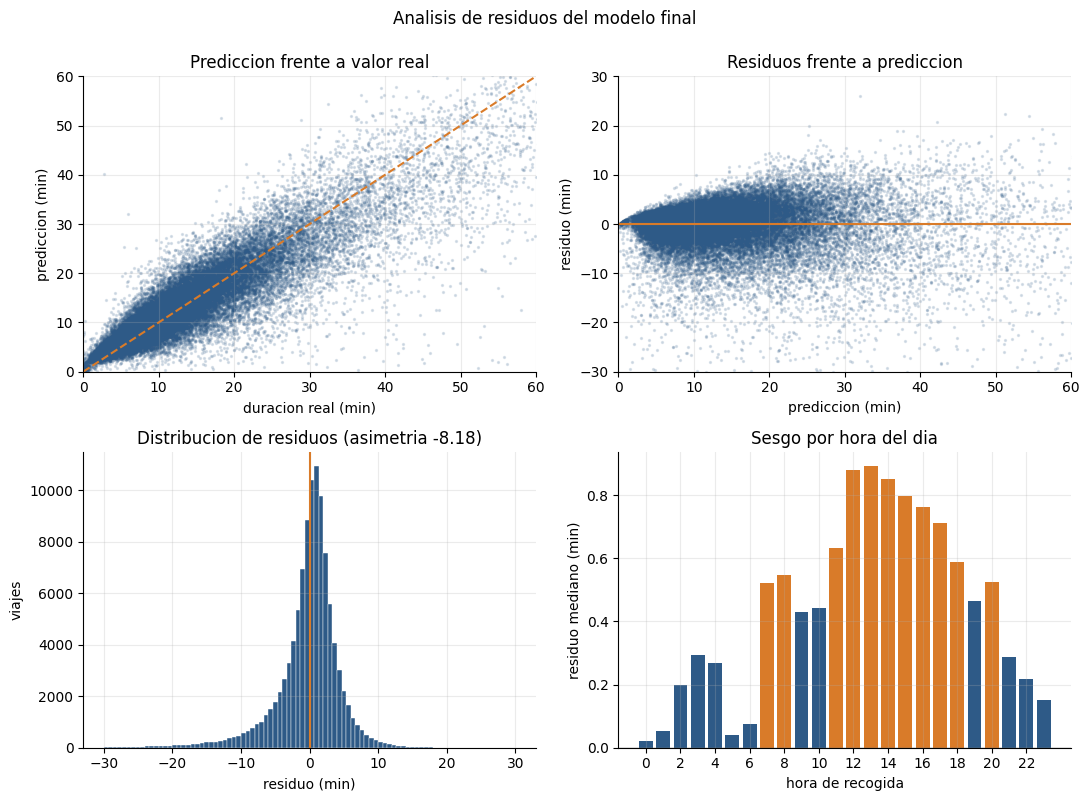

In [0]:
fig, ax = plt.subplots(2, 2, figsize=(11, 8))
m = res.sample(min(40_000, len(res)), random_state=config.SEMILLA)

ax[0, 0].scatter(m.real / 60, m.pred / 60, s=2, alpha=0.15, color=AZUL)
ax[0, 0].plot([0, 60], [0, 60], "--", color=NARANJA, lw=1.5)
ax[0, 0].set(xlim=(0, 60), ylim=(0, 60), xlabel="duracion real (min)",
             ylabel="prediccion (min)", title="Prediccion frente a valor real")

ax[0, 1].scatter(m.pred / 60, m.residuo_min, s=2, alpha=0.15, color=AZUL)
ax[0, 1].axhline(0, color=NARANJA, lw=1.5)
ax[0, 1].set(xlim=(0, 60), ylim=(-30, 30), xlabel="prediccion (min)",
             ylabel="residuo (min)", title="Residuos frente a prediccion")

ax[1, 0].hist(res.residuo_min, bins=90, range=(-30, 30), color=AZUL,
              edgecolor="white", linewidth=0.3)
ax[1, 0].axvline(0, color=NARANJA, lw=1.5)
ax[1, 0].set(xlabel="residuo (min)", ylabel="viajes",
             title=f"Distribucion de residuos (asimetria {res.residuo_min.skew():.2f})")

por_hora = res.groupby("pickup_hour").residuo_min.median()
ax[1, 1].bar(por_hora.index, por_hora.values,
             color=[NARANJA if abs(v) > 0.5 else AZUL for v in por_hora.values])
ax[1, 1].axhline(0, color=GRIS, lw=1)
ax[1, 1].set(xlabel="hora de recogida", ylabel="residuo mediano (min)",
             xticks=range(0, 24, 2), title="Sesgo por hora del dia")

fig.suptitle("Analisis de residuos del modelo final", y=0.995, fontsize=12)
plt.tight_layout()
guardar_figura(fig, "08_residuos_modelo")
plt.show()

In [0]:
print("Residuo mediano por segmento (minutos)")
print(f"  viajes de aeropuerto : {res[res.es_aeropuerto == 1].residuo_min.median():6.2f}")
print(f"  resto de la ciudad   : {res[res.es_aeropuerto == 0].residuo_min.median():6.2f}")

print("\nError por tramo de distancia")
for lo, hi in [(0, 2), (2, 5), (5, 10), (10, 20), (20, 100)]:
    sel = res[(res.distancia_haversine_km > lo) & (res.distancia_haversine_km <= hi)]
    if len(sel) > 50:
        print(f"  {lo:>3}-{hi:<4} km  n={len(sel):>6,}  "
              f"error absoluto mediano {sel.residuo_min.abs().median():5.2f} min  "
              f"sesgo {sel.residuo_min.median():+5.2f} min")

Residuo mediano por segmento (minutos)
  viajes de aeropuerto :  -0.12
  resto de la ciudad   :   0.47

Error por tramo de distancia
    0-2    km  n=48,883  error absoluto mediano  1.51 min  sesgo +0.39 min
    2-5    km  n=37,034  error absoluto mediano  2.31 min  sesgo +0.67 min
    5-10   km  n=13,054  error absoluto mediano  3.50 min  sesgo +0.44 min
   10-20   km  n= 5,136  error absoluto mediano  4.85 min  sesgo -0.22 min
   20-100  km  n= 1,815  error absoluto mediano  5.89 min  sesgo -1.59 min


### Interpretacion: el modelo es conservador con los trayectos largos

Los residuos presentan una asimetria fuertemente negativa, y el detalle
revela dos comportamientos distintos que la media por si sola esconde: la
mediana del residuo es ligeramente **positiva** mientras que la media es
**negativa**. El modelo sobreestima de forma leve el viaje habitual y
subestima de forma severa unos pocos trayectos excepcionalmente lentos.

La tabla por tramo de distancia lo confirma: el sesgo pasa de positivo en
los recorridos cortos a negativo en los de mas de veinte kilometros.

La causa es identificable. Esos viajes tardaron mucho mas de lo que su
distancia, hora y zona permitirian anticipar, lo que apunta a incidentes
—accidentes, cierres de via, condiciones meteorologicas adversas— que no
estan representados en ninguna variable disponible. Es el mismo fenomeno
que el INSIGHT-06 identifico en la serie diaria con la tormenta del 23 de
enero: eventos reales que el modelo no puede prever porque carece de la
informacion que los explicaria.

**Consecuencia operativa.** El error no se distribuye de forma uniforme, de
modo que la ventana comunicada al pasajero debe ser **asimetrica**: el
riesgo de tardar mucho mas de lo previsto es considerablemente mayor que el
de llegar antes. Un intervalo simetrico alrededor de la prediccion
subestimaria sistematicamente el peor caso.

**Linea de trabajo natural.** Incorporar datos meteorologicos y de
incidentes de trafico es la extension que atacaria directamente esta cola,
y es donde cabria esperar la mayor ganancia adicional del modelo.

In [0]:
# Cuantificacion de la cola: que proporcion de los residuos la genera.
umbral = 15  # minutos
cola = res[res.residuo_min < -umbral]
print(f"Viajes subestimados en mas de {umbral} min: {len(cola):,} "
      f"({len(cola)/len(res)*100:.2f} % del total)")
print(f"  duracion real mediana de esos viajes : {cola.real.median()/60:.1f} min")
print(f"  duracion real mediana del resto      : {res[res.residuo_min >= -umbral].real.median()/60:.1f} min")
print(f"  contribucion de esa cola al error cuadratico total: "
      f"{(cola.residuo_min**2).sum() / (res.residuo_min**2).sum()*100:.1f} %")

Viajes subestimados en mas de 15 min: 2,037 (1.91 % del total)
  duracion real mediana de esos viajes : 47.2 min
  duracion real mediana del resto      : 11.1 min
  contribucion de esa cola al error cuadratico total: 53.0 %


**Sobre la normalidad de los residuos.** No se aplica ninguna prueba
formal, y la omision es deliberada. Con cien mil observaciones, contrastes
como Shapiro-Wilk o Kolmogorov-Smirnov rechazan la normalidad de forma
practicamente automatica: detectan cualquier desviacion por irrelevante que
sea, de modo que el valor p resultante mide el tamano de la muestra mas que
la forma de la distribucion.

Se reportan en su lugar la asimetria y el histograma, que describen la
magnitud de la desviacion y no su significancia. Conviene ademas recordar
que la normalidad de los residuos no es requisito para la calidad
predictiva: solo interviene en la construccion de intervalos de confianza
parametricos, que aqui no se emplean.

## 9. Importancia de variables

Se emplea importancia por permutacion y no la importancia interna del
modelo. La segunda mide cuantas veces se uso cada variable para dividir un
nodo, lo que favorece a las de alta cardinalidad; la primera mide la
degradacion real del error al desordenar cada variable, que es lo que
interesa.

variable                   importancia      desv
distancia_haversine_km          1.4597    0.0061
pickup_hour                     0.1465    0.0003
bearing_deg                     0.0704    0.0018
dropoff_cluster                 0.0445    0.0018
pickup_dayofweek                0.0331    0.0013
pickup_cluster                  0.0221    0.0002
vendor_id                       0.0197    0.0035
distancia_manhattan_km          0.0039    0.0002
passenger_count                 0.0036    0.0006
es_aeropuerto                   0.0024    0.0005
is_weekend                      0.0009    0.0001
pickup_month                    0.0000    0.0000
store_and_fwd_flag             -0.0001    0.0000


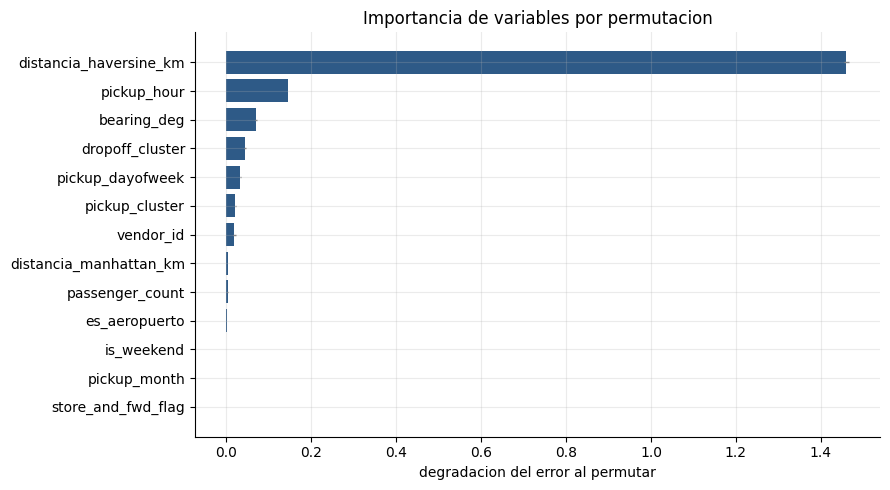

In [0]:
sub = np.random.RandomState(config.SEMILLA).choice(len(Xte), min(20_000, len(Xte)), replace=False)
imp = permutation_importance(
    modelo_final, Xte[sub], np.log1p(y_test[sub]),
    n_repeats=3, random_state=config.SEMILLA, n_jobs=-1,
)

orden = np.argsort(imp.importances_mean)[::-1]
print(f"{'variable':<26}{'importancia':>12}{'desv':>10}")
for i in orden:
    print(f"{COLS[i]:<26}{imp.importances_mean[i]:>12.4f}{imp.importances_std[i]:>10.4f}")

fig, ax = plt.subplots(figsize=(9, 5))
pos = np.arange(len(orden))
ax.barh(pos, imp.importances_mean[orden], xerr=imp.importances_std[orden],
        color=AZUL, error_kw={"ecolor": GRIS, "lw": 1})
ax.set(yticks=pos, xlabel="degradacion del error al permutar",
       title="Importancia de variables por permutacion")
ax.set_yticklabels([COLS[i] for i in orden])
ax.invert_yaxis()
plt.tight_layout()
guardar_figura(fig, "09_importancia_variables")
plt.show()

### Contraste con el analisis exploratorio

In [0]:
if eda:
    previsto = eda["orden_esperado_importancia"]
    obtenido = [COLS[i] for i in orden]
    comunes = [f for f in previsto if f in obtenido]

    print(f"{'factor':<24}{'prevista':>10}{'obtenida':>10}")
    for f in comunes:
        print(f"{f:<24}{previsto.index(f) + 1:>10}{obtenido.index(f) + 1:>10}")

    concordancia = np.corrcoef([previsto.index(f) for f in comunes],
                               [obtenido.index(f) for f in comunes])[0, 1]
    print(f"\nCorrelacion de rangos entre lo previsto y lo obtenido: {concordancia:.3f}")
else:
    print("Sin artefacto del analisis exploratorio; se omite la comparacion.")

factor                    prevista  obtenida
pickup_hour                      1         2
dropoff_cluster                  2         4
pickup_cluster                   3         6
pickup_dayofweek                 4         5
es_aeropuerto                    5        10
pickup_month                     6        12
passenger_count                  7         9
vendor_id                        8         7

Correlacion de rangos entre lo previsto y lo obtenido: 0.730


**Como leer esta comparacion.** El analisis exploratorio ordeno los factores
por su efecto parcial sobre la duracion, y aqui se contrasta ese orden con
la importancia que el modelo asigno de forma independiente. Una
concordancia alta indica que el modelo aprendio la estructura que el
analisis identifico y no un atajo espurio.

Dos comportamientos estaban anticipados y conviene verificarlos:

- **`es_aeropuerto` con importancia practicamente nula.** Su efecto
  marginal era el mayor de todos los factores, pero el parcial resulto
  reducido: los viajes de aeropuerto tardan mas por ser mas largos, no por
  una dinamica propia (INSIGHT-05). El modelo confirma que la distancia
  absorbe por completo ese efecto.
- **`distancia_manhattan_km` con aporte marginal** pese a ser una de las
  variables mas informativas. Es un artefacto conocido de la importancia
  por permutacion ante variables correlacionadas: al permutar una, la otra
  compensa y el error apenas se degrada. Con una correlacion de 0,99
  (INSIGHT-08), ambas deben interpretarse conjuntamente y no por separado.

En cambio, que una variable **sin efecto medido** apareciera entre las mas
importantes obligaria a revisar si esta filtrando informacion del target.

## 10. Persistencia

In [0]:
resumen = {
    "modelo": "HistGradientBoostingRegressor",
    "justificacion_nodo_unico": (
        f"El conjunto de entrenamiento ocupa {memoria_mb:.0f} MB en memoria. "
        "A ese volumen el entrenamiento distribuido paga coordinacion sin "
        "beneficio, y la cache de modelos de Spark Connect en computo "
        "serverless esta limitada a 1 GB."
    ),
    "hiperparametros": hp,
    "seleccion_hiperparametros": f"validacion temporal hacia adelante, {len(ventanas)} ventanas",
    "target": "log1p(trip_duration), invertido con expm1 antes de medir",
    "recorte_prediccion": [config.DURACION_MIN_SEG, config.DURACION_MAX_SEG],
    "n_train": int(len(train)),
    "n_test": int(len(test)),
    "metricas_test": {k: round(v, 6) for k, v in r_final.items() if k != "modelo"},
    "metricas_train": {k: round(v, 6) for k, v in r_train.items() if k != "modelo"},
    "lectura_negocio": negocio,
    "comparacion": [{k: (round(v, 6) if isinstance(v, float) else v) for k, v in r.items()}
                    for r in resultados],
    "importancias": {COLS[i]: round(float(imp.importances_mean[i]), 6) for i in orden},
    "busqueda_hiperparametros": busqueda,
}

with open(f"{RUTA_ARTEFACTOS}/modelo_resumen.json", "w") as fh:
    json.dump(resumen, fh, indent=2, ensure_ascii=False)

print(f"Resumen guardado en {RUTA_ARTEFACTOS}/modelo_resumen.json")
print(f"Modelo registrado en el experimento {config.EXPERIMENTO_MLFLOW}")

Resumen guardado en /Volumes/nyc_taxi/gold/artifacts/modelo_resumen.json
Modelo registrado en el experimento /Shared/nyc_taxi_trip_duration
